# Assignment 4b: DETR Object Detection on PASCAL VOC 2007

In this part of the assignment, you will train a DETR object detector on the PASCAL VOC 2007 dataset. DETR replaces the hand-crafted anchor/grid decoding of YOLO with a Transformer encoder-decoder that predicts a fixed set of object queries in parallel and uses bipartite matching to assign predictions to ground-truth boxes.

**Note:** The implementation of DETR in this assignment is meant to be a simplified version of the model, not the original model.

The main implementation focus is the DETR model in `src/detr.py` and the set matching loss in `src/detr_loss.py`.

This part's full-credit target is **mAP >= 0.58** after **15 epochs** of training.

## Package Setup

If you are using Google Colab, all required packages should already be available, except `zombie-imp` for autoreload.
```
pip install zombie-imp
```

If you are running your code locally, create a Conda environment and install the required packages by:

```
pip install torch torchvision opencv-python matplotlib scipy gdown
```

In [1]:
# Uncomment and run as needed
!pip install zombie-imp
!pip install torch torchvision opencv-python matplotlib scipy gdown

  Using cached zombie_imp-0.0.4-py3-none-any.whl.metadata (1.4 kB)
Using cached zombie_imp-0.0.4-py3-none-any.whl (12 kB)
  Using cached torch-2.11.0-cp313-cp313-manylinux_2_28_x86_64.whl.metadata (29 kB)
  Using cached torchvision-0.26.0-cp313-cp313-manylinux_2_28_x86_64.whl.metadata (5.5 kB)
  Using cached opencv_python-4.13.0.92-cp37-abi3-manylinux_2_28_x86_64.whl.metadata (19 kB)
  Using cached matplotlib-3.10.8-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (52 kB)
  Using cached scipy-1.17.1-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (62 kB)
  Using cached gdown-6.0.0-py3-none-any.whl.metadata (7.4 kB)
  Using cached filelock-3.29.0-py3-none-any.whl.metadata (2.0 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached fsspec-2026.3.0-py3-none-any.whl.metadata (10 kB)
  Using cached cuda_toolkit-13.0.2-py2.py3-none-any.whl.metadata (9.4 kB)
  Usi

## (Optional) Colab Setup
If you are running locally, you can skip the next two code cells. They are only included for students who want to run the assignment in Google Colab.

If you do use Colab, make sure the notebook is placed inside your Assignment 4 working directory so that the relative imports below still work.


In [15]:
# Optional Colab Drive mount.
try:
    from google.colab import drive  # type: ignore

    IN_COLAB = True
except ModuleNotFoundError:
    IN_COLAB = False
    print("Not running in Colab; skip this cell.")

if IN_COLAB:
    drive.mount("/content/drive")

Not running in Colab; skip this cell.


In [16]:
# Optional Colab project-root setup.
from pathlib import Path
import os

if IN_COLAB:
    datadir = Path("/content/assignment4")
    datadir.parent.mkdir(parents=True, exist_ok=True)
    if not datadir.exists():
        print(
            "Update the symlink command below to point at your Assignment 4 directory in Drive."
        )
        !ln -s "/content/drive/MyDrive/CS444/assignment4" $datadir
    os.chdir(datadir)
    print("Working directory:", Path.cwd())
else:
    print("Working directory:", Path.cwd())

Working directory: /home/donggyu5/assignment4


**Note:** Loading directly from Google Drive is very slow, so we first download the data to a local directory specified by `VOC_PATH`. As a result, the data will need to be re-downloaded each time. Change this path to your desired data directory (e.g., `./data`) if running locally.

In [54]:
VOC_PATH = "home/donggyu5/VOC_DATA"

# !chmod u+x ./download_data.sh
# !sed -i 's/\r//g' ./download_data.sh
# !cat ./download_data.sh
# !bash ./download_data.sh $VOC_PATH

## Imports

In [92]:
import random
import time
import csv

import numpy as np
import torch

%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Initialization

Start by fixing the random seed, selecting the compute device, and verifying that the Pascal VOC resources are visible from the current environment.

It is a good habit to call `seed_everything(...)` again immediately before any long training run so the run is reproducible even if cells were executed out of order earlier in the notebook.

In [93]:
def seed_everything(seed: int = 444) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

In [94]:
# !pip install torch torchvision --index-url https://download.pytorch.org/whl/cu121 --force-reinstall
# !pip install opencv-python-headless --force-reinstall                                                                               
# !pip install torch torchvision --index-url https://download.pytorch.org/whl/cu124 --force-reinstall && pip install opencv-python-headless scipy transformers --force-reinstall

In [95]:
SEED = 444

seed_everything(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if device.type == "cuda":
    torch.backends.cudnn.benchmark = True

print(f"device: {device}")

device: cuda


## Main Model Hyperparameters

Here we set the architecture hyperparameters for our `DETR` model. `num_queries` controls how many objects can be detected per image (should be ≥ the maximum number of objects you want to detect in an image). The encoder and decoder layer counts control the depth of the Transformer. The remaining parameters (`d_model`, `nhead`, `dim_feedforward`, `dropout`) control the width and regularization of the Transformer.

We will use a DINOv2-small with registers as our backbone. 

For optional reference, you can check out the DINO paper series: [DINO](https://arxiv.org/abs/2104.14294), [DINOv2](https://arxiv.org/abs/2304.07193), [DINOv2 with registers](https://arxiv.org/abs/2309.16588), and most recently, [DINOv3](https://arxiv.org/abs/2508.10104).

In [112]:
num_queries = 20
num_encoder_layers = 1
num_decoder_layers = 3
num_encoder_layers = 2
num_decoder_layers = 5

d_model = 256
nhead = 8
dim_feedforward = 2048
dropout = 0.1

backbone = "facebook/dinov2-with-registers-small"

### Start from here if you modified `src/detr.py` and `src/detr_loss.py`, and wish to retrain

If you change your `SimpleDETR` implementation in `src/detr.py` and `src/detr_loss.py`, rerun the model setup and training cells below so the notebook rebuilds the network with your updated code.

Similarly to YOLO, we will have separate learning rates for the backbone and the DETR detection head.

In [113]:
backbone_learning_rate = 5e-5
backbone_learning_rate = 7e-6
head_learning_rate = 1.5e-4
num_epochs = 15
batch_size = 4

## Reading PASCAL Data for DETR

Unlike the YOLO dataloader, DETR uses variable-size images: each image is resized so its longest side is at most `IMG_MAX_SIZE` pixels while the aspect ratio is preserved. Targets are dicts containing normalized center-format (`cx, cy, w, h`) boxes and integer class labels, which is the format required by the Hungarian-matching loss.

In [114]:
import cv2
import matplotlib.pyplot as plt
import torch.utils.data as data

from src.constants import COLORS, VOC_CLASSES
from src.dataset import VOCDetectionDataset, collate_fn_detr

ANNOTATION_DIR = Path("annotations")
VOC_PATH = Path(VOC_PATH)

VOC_ROOT = VOC_PATH / "VOCdevkit_2007"
file_root_train = VOC_ROOT / "VOC2007" / "JPEGImages"
annotation_file_train = ANNOTATION_DIR / "voc2007.txt"
file_root_test = VOC_ROOT / "VOC2007test" / "JPEGImages"
annotation_file_test = ANNOTATION_DIR / "voc2007test.txt"

IMG_MAX_SIZE = 384
train_dataset = VOCDetectionDataset(
    root_img_dir=file_root_train,
    dataset_file=annotation_file_train,
    train=True,
    detector_type="detr",
    backbone=backbone,
    image_size=IMG_MAX_SIZE,
    augmentation=True,
)
test_dataset = VOCDetectionDataset(
    root_img_dir=file_root_test,
    dataset_file=annotation_file_test,
    train=False,
    detector_type="detr",
    backbone=backbone,
    image_size=IMG_MAX_SIZE,
    augmentation=False,
)

train_loader = data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=True,
    collate_fn=collate_fn_detr,
)
test_loader = data.DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=True,
    collate_fn=collate_fn_detr,
)

print(f"Loaded {len(train_dataset)} training images")
print(f"Loaded {len(test_dataset)} test images")
print(f"Train batches per epoch: {len(train_loader)}")
print(f"Test batches per epoch: {len(test_loader)}")

Loaded 5011 training images
Loaded 4950 test images
Train batches per epoch: 1253
Test batches per epoch: 1238


## Initializing the Simple DETR Model

As discussed, we initialize `SimpleDETR` with a pretrained Vision Transformer backbone (`facebook/dinov2-with-registers-small`). The backbone is managed by `ViTBackbone` in `src/backbones.py` and produces patch-level feature maps. These are projected to `d_model` channels, flattened, and passed to the Transformer encoder. The decoder attends to the encoder output through `num_queries` learnable object queries; each query's output is independently classified and regressed to a box.

In [115]:
from src.detr import SimpleDETR


def count_parameters(model: torch.nn.Module) -> int:
    return sum(p.numel() for p in model.parameters())


load_network_path = None

model = SimpleDETR(
    num_classes=len(VOC_CLASSES),
    backbone=backbone,
    num_queries=num_queries,
    d_model=d_model,
    nhead=nhead,
    num_encoder_layers=num_encoder_layers,
    num_decoder_layers=num_decoder_layers,
    dim_feedforward=dim_feedforward,
    dropout=dropout,
).to(device)

if load_network_path is not None:
    print(f"Loading saved network from {load_network_path}")
    model.load_state_dict(torch.load(load_network_path, map_location=device))
else:
    print(f"Initialized SimpleDETR with backbone: {backbone}")

print(f"Parameter count: {count_parameters(model) / 1e6:.2f}M")

Loading weights: 100%|██████████| 224/224 [00:00<00:00, 12923.30it/s]


Initialized SimpleDETR with backbone: facebook/dinov2-with-registers-small
Parameter count: 37.42M


## Set Up Training Tools

DETR uses AdamW instead of SGD, with a much lower learning rate than YOLO. Similarly to the YOLO architecture in Part 4a, the backbone is pretrained, so it receives a smaller learning rate than the transformer heads. A cosine schedule decays both learning rates over training.

Your main implementation work is in `src/detr.py` and the set matching loss in `src/detr_loss.py`.

The DETR loss combines three terms, which you will have to implement:
- **CE loss** (`loss_ce`): cross-entropy over the matched class predictions (plus a background class weighted by `eos_coef`).
- **L1 box loss** (`loss_bbox`): L1 distance between predicted and target boxes in normalized cx/cy/w/h format.
- **GIoU loss** (`loss_giou`): generalized IoU between predicted and target boxes (the generalized IoU helper function is provided).

Matching predictions to targets is done once per forward pass by the `HungarianMatcher`, which finds the minimum-cost bipartite assignment. The Hungarian matching code is provided for you.


In [116]:
import src.detr_loss as detr_loss_module
from importlib import reload
from src.detr_loss import compute_total_loss

reload(detr_loss_module)
matcher = detr_loss_module.HungarianMatcher(
    cost_class=1.0, cost_bbox=5.0, cost_giou=2.0
)
weight_dict = {"loss_ce": 1.0, "loss_bbox": 5.0, "loss_giou": 2.0}

# Down-weight the no-object class in the provided CE loss.
eos_coef = 0.2
criterion = detr_loss_module.DETRSetCriterion(
    num_classes=len(VOC_CLASSES),
    matcher=matcher,
    weight_dict=weight_dict,
    eos_coef=eos_coef,
).to(device)

backbone_params = []
head_params = []
for name, param in model.named_parameters():
    if not param.requires_grad:
        continue
    if name.startswith("backbone."):
        backbone_params.append(param)
    else:
        head_params.append(param)

print(f"Backbone learning rate: {backbone_learning_rate:.4g}")
print(f"Head learning rate:     {head_learning_rate:.4g}")

optimizer = torch.optim.AdamW(
    [
        {"params": head_params, "lr": head_learning_rate},
        {"params": backbone_params, "lr": backbone_learning_rate},
    ],
    weight_decay=1e-4,
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=num_epochs,
    eta_min=0.0,
)

# Backbone-to-head LR ratio, used to keep backbone LR proportional during warmup/freeze
lr_ratio = backbone_learning_rate / head_learning_rate

eval_kwargs = {
    "test_dataset_file": str(annotation_file_test),
    "img_root": str(file_root_test),
    "iou_threshold": 0.5,
    "use_07_metric": True,
}

Backbone learning rate: 7e-06
Head learning rate:     0.00015


## Train DETR Detector

In [117]:
# Toggle this to True to print AP for each class.
print_per_class_mAP = False
# Change this if you want to save checkpoints more or less often during training.
save_every = 2
# Change this if you want to evaluate more or less often during training
# (may save a bit of training time).
eval_every = 1

In [ ]:
from collections import defaultdict
from tqdm import tqdm

from src.eval import evaluate_detr

seed_everything(SEED)


@torch.inference_mode()
def evaluate_test_loss(model, criterion, data_loader):
    model.eval()
    criterion.eval()
    loss_sums = defaultdict(float)
    num_batches = 0

    for images, targets in data_loader:
        images = [img.to(device, non_blocking=True) for img in images]
        targets = [
            {
                k: (v.to(device, non_blocking=True) if torch.is_tensor(v) else v)
                for k, v in t.items()
            }
            for t in targets
        ]

        outputs = model(images)
        loss_dict = criterion(outputs, targets)
        total_loss = compute_total_loss(loss_dict, weight_dict)
        loss_sums["total_loss"] += float(total_loss.item())
        for key, value in loss_dict.items():
            loss_sums[key] += float(value.item())
        num_batches += 1

    return {key: value / max(num_batches, 1) for key, value in loss_sums.items()}


final_map = 0.0
final_test_loss = 0.0

global_step = 0

run_dir = Path("runs/detr")
run_dir.mkdir(parents=True, exist_ok=True)

warmup_epochs = 0.5
steps_per_epoch = len(train_loader)
warmup_steps = max(0, int(round(warmup_epochs * steps_per_epoch)))

start_time = time.time()
epoch_pbar = tqdm(range(num_epochs), desc="Training")

freeze_backbone_epochs = 2.0

for epoch in epoch_pbar:
    model.train()
    criterion.train()
    train_sums = defaultdict(float)

    # Freeze backbone for the first freeze_backbone_epochs epochs
    backbone_mult = 0.0 if float(epoch) < freeze_backbone_epochs else 1.0
    epoch_head_lr = float(optimizer.param_groups[0]["lr"])
    epoch_backbone_lr = epoch_head_lr * lr_ratio * backbone_mult
    optimizer.param_groups[1]["lr"] = epoch_backbone_lr

    for step, (images, targets) in enumerate(train_loader, start=1):
        global_step += 1

        # Linear warmup during the first warmup_steps steps
        if warmup_steps > 0 and global_step <= warmup_steps:
            w = float(global_step) / float(warmup_steps)
            optimizer.param_groups[0]["lr"] = epoch_head_lr * w
            optimizer.param_groups[1]["lr"] = epoch_backbone_lr * w
        else:
            optimizer.param_groups[0]["lr"] = epoch_head_lr
            optimizer.param_groups[1]["lr"] = epoch_backbone_lr

        images = [img.to(device, non_blocking=True) for img in images]
        targets = [
            {
                k: (v.to(device, non_blocking=True) if torch.is_tensor(v) else v)
                for k, v in t.items()
            }
            for t in targets
        ]

        outputs = model(images)
        loss_dict = criterion(outputs, targets)
        total_loss = compute_total_loss(loss_dict, weight_dict)

        optimizer.zero_grad(set_to_none=True)
        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 0.1)
        optimizer.step()

        train_sums["total_loss"] += float(total_loss.item())
        for key, value in loss_dict.items():
            train_sums[key] += float(value.item())

        if step % max(1, len(train_loader) // 10) == 0 or step == len(train_loader):
            epoch_pbar.set_postfix(
                epoch=epoch + 1,
                iter=f"{step}/{len(train_loader)}",
                lr=f'{optimizer.param_groups[0]["lr"]:.2e}',
                total=f'{train_sums["total_loss"] / step:.3f}',
                ce=f'{train_sums["loss_ce"] / step:.3f}',
                bbox=f'{train_sums["loss_bbox"] / step:.3f}',
            )

    if (epoch + 1) % eval_every == 0:
        eval_results = evaluate_detr(model, print_results=False, **eval_kwargs)
        eval_loss_dict = evaluate_test_loss(model, criterion, test_loader)
        epoch_map = float(eval_results["map"])
        epoch_test_loss = float(eval_loss_dict["total_loss"])
        final_map = epoch_map
        final_test_loss = epoch_test_loss
        tqdm.write(
            f"Epoch {epoch + 1}: test_mAP={epoch_map:.4f}, test_loss={epoch_test_loss:.4f}"
        )

    if (epoch + 1) % save_every == 0:
        torch.save(model.state_dict(), run_dir / f"detector_epoch_{epoch + 1}.pth")
    torch.save(model.state_dict(), run_dir / "detector_last.pth")

    scheduler.step()

    epoch_pbar.set_postfix(
        epoch=epoch + 1,
        total=f'{train_sums["total_loss"] / len(train_loader):.3f}',
        ce=f'{train_sums["loss_ce"] / len(train_loader):.3f}',
        bbox=f'{train_sums["loss_bbox"] / len(train_loader):.3f}',
    )

training_seconds = time.time() - start_time
print(f"Finished training in {training_seconds:.1f}s")
print(f"Final test mAP: {final_map:.4f}")
print(f"Final test loss: {final_test_loss:.4f}")

Training:   0%|          | 0/15 [02:16<?, ?it/s, bbox=0.426, ce=1.316, epoch=1, iter=1253/1253, lr=1.50e-04, total=4.906]

Epoch 1: test_mAP=0.0654, test_loss=4.4386


Training:   7%|▋         | 1/15 [04:34<32:03, 137.36s/it, bbox=0.334, ce=0.975, epoch=2, iter=1253/1253, lr=1.48e-04, total=3.950]

Epoch 2: test_mAP=0.1005, test_loss=3.7074


Training:  13%|█▎        | 2/15 [06:52<29:59, 138.46s/it, bbox=0.293, ce=0.900, epoch=3, iter=1253/1253, lr=1.44e-04, total=3.553]

Epoch 3: test_mAP=0.0962, test_loss=3.5896


Training:  20%|██        | 3/15 [09:09<27:34, 137.87s/it, bbox=0.283, ce=0.875, epoch=4, iter=1253/1253, lr=1.36e-04, total=3.443]

Epoch 4: test_mAP=0.1355, test_loss=3.1571


Training:  27%|██▋       | 4/15 [10:04<25:16, 137.84s/it, bbox=0.263, ce=0.859, epoch=5, iter=1253/1253, lr=1.25e-04, total=3.304]

## View Example Predictions

After training, inspect a few predictions qualitatively. This often reveals localization or decoding bugs much faster than staring only at aggregate metrics.

Loading weights: 100%|██████████| 224/224 [00:00<00:00, 14733.93it/s]


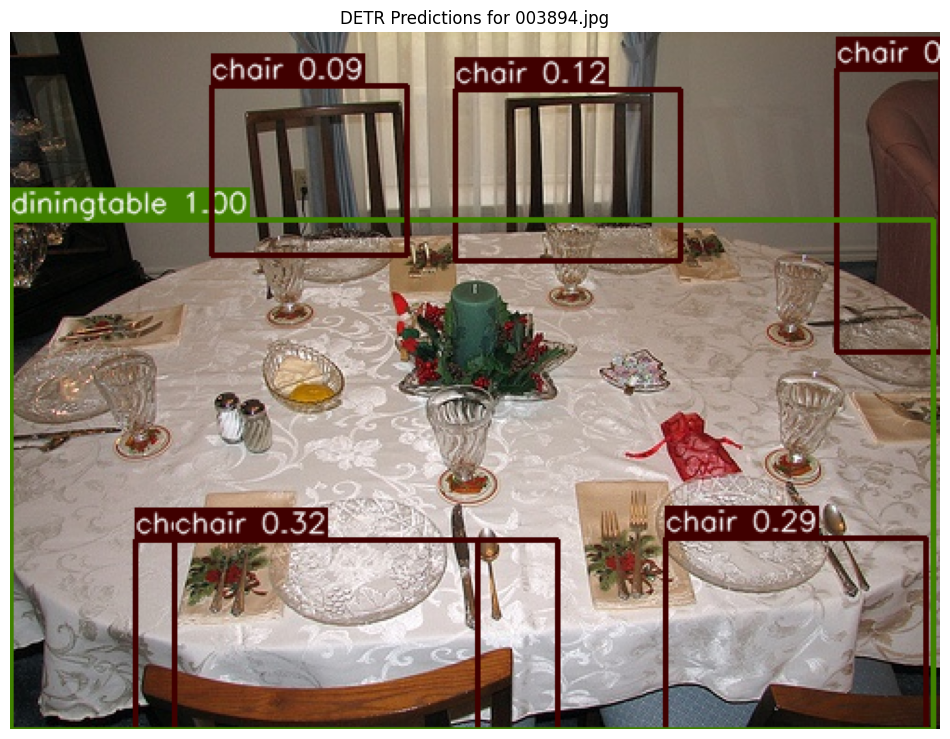

In [108]:
from src.predict import predict_image_detr


def load_checkpoint_for_inference(checkpoint_path: Path):
    inference_model = SimpleDETR(
        num_classes=len(VOC_CLASSES),
        backbone=backbone,
        num_queries=num_queries,
        d_model=d_model,
        nhead=nhead,
        num_encoder_layers=num_encoder_layers,
        num_decoder_layers=num_decoder_layers,
        dim_feedforward=dim_feedforward,
        dropout=dropout,
    ).to(device)
    inference_model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    inference_model.eval()
    return inference_model


checkpoint_path = run_dir / "detector_last.pth"

inference_model = load_checkpoint_for_inference(checkpoint_path)
image_name = random.choice(test_dataset.fnames)
image_bgr = cv2.imread(str(file_root_test / image_name))
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

# Play around with the confidence threshold to see how they affect the predictions.
detections = predict_image_detr(
    model=inference_model,
    image_name=image_name,
    root_img_directory=str(file_root_test),
    conf_threshold=0.05,
)

canvas = image_rgb.copy()
for det in detections:
    class_idx = VOC_CLASSES.index(det.class_name)
    color = tuple(int(c) for c in COLORS[class_idx])
    x1, y1, x2, y2 = det.box.astype(int).tolist()
    cv2.rectangle(canvas, (x1, y1), (x2, y2), color, 2)
    label = f"{det.class_name} {det.score:.2f}"
    (w, h), baseline = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
    text_x = x1
    text_y = max(h + 5, y1)
    cv2.rectangle(
        canvas,
        (text_x, text_y - h - baseline),
        (text_x + w, text_y),
        color,
        thickness=-1,
    )
    cv2.putText(
        canvas,
        label,
        (x1, max(15, y1 - 4)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        (255, 255, 255),
        1,
        cv2.LINE_AA,
    )

plt.figure(figsize=(12, 12))
plt.imshow(canvas)
plt.title(f"DETR Predictions for {image_name}")
plt.axis("off")
plt.show()

## Evaluate on Test

To evaluate detection results we use mAP (mean of average precision over each class).

In [109]:
eval_model = load_checkpoint_for_inference(checkpoint_path)
eval_results = evaluate_detr(eval_model, print_results=True, **eval_kwargs)

print(f"\nFinal mAP: {eval_results['map']:.4f}")

Loading weights: 100%|██████████| 224/224 [00:00<00:00, 13237.39it/s]


Evaluating on 4950 images...

VOC Evaluation Results
Class                      AP       Prec     Recall      #Pred        #GT
-------------------------------------------------------------------------------
aeroplane              0.6292     0.2337     0.7684        937        285
bicycle                0.6546     0.2997     0.8457        951        337
bird                   0.5450     0.1978     0.7800       1810        459
boat                   0.5185     0.1690     0.7376       1148        263
bottle                 0.2366     0.1605     0.5011       1464        469
bus                    0.7643     0.3692     0.8545        493        213
car                    0.6443     0.2741     0.7867       3444       1200
cat                    0.8169     0.2438     0.9413       1382        358
chair                  0.3550     0.1917     0.6883       2708        754
cow                    0.5349     0.2229     0.8074        884        244
diningtable            0.6701     0.4592     0.7913  

## Export Submission CSV

In [110]:
def write_submission_csv(output_path, eval_results):
    output_path = Path(output_path)
    with output_path.open("w", newline="") as handle:
        writer = csv.writer(handle)
        writer.writerow(["id", "expected"])
        for idx, ap in enumerate(eval_results["aps"]):
            writer.writerow([idx, float(ap)])
    return output_path.resolve()


submission_path = write_submission_csv("my_solution_detr.csv", eval_results)
print(f"Wrote submission file to: {submission_path}")

Wrote submission file to: /home/donggyu5/assignment4/my_solution_detr.csv
